# Exploratory Data Analysis — Movie NLP Success Analyzer

**Phase 1 (KT1)** — SIAP, University of Novi Sad, Faculty of Technical Sciences  
**Team:** Laslo Uri (E2 163/2023), Denis Dautović (E2 166/2023), Nikola Janković (E2 130/2025)  
**Date:** March 2026

This notebook explores the main movie dataset (`final_movie_list.csv`, 12,950 movies) covering:
- Dataset structure and quality
- Target variable distributions
- Financial patterns, genre effects, temporal trends
- Missing data and modeling eligibility
- Subtitle coverage and feature correlations

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_main_dataset, safe_literal_eval
from src.eda_plots import (
    plot_target_distributions,
    plot_financial_distributions,
    plot_budget_vs_revenue,
    plot_financial_boxplots,
    plot_genre_frequency,
    plot_genre_success_rates,
    plot_genre_cooccurrence,
    plot_temporal_production,
    plot_temporal_financials,
    plot_temporal_success_rates,
    plot_runtime_votes_distributions,
    plot_runtime_votes_by_success,
    plot_missing_data_heatmap,
    plot_subtitle_coverage,
    plot_feature_correlations,
    plot_point_biserial_correlations,
)

plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'raw'
SUBTITLES_DIR = RAW_DIR / 'subtitles'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

---
## 1. Dataset Overview

Load the main dataset using `src.data_loader`. The loader parses the genres column into Python lists and computes ROI (`revenue / budget`).

In [2]:
df = load_main_dataset(PROCESSED_DIR)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded main dataset: 12,950 movies
Shape: (12950, 15)
Columns: ['id', 'budget', 'revenue', 'imdb_id', 'runtime', 'release_date', 'genres', 'original_title', 'title', 'vote_count', 'is_commercial', 'is_award_winner', 'is_popular', 'genres_list', 'roi']


**Conclusion:** The dataset contains 12,950 movies and 15 columns. The target variables are `is_commercial` (ROI ≥ 2), `is_award_winner`, and `is_popular` — this table is the primary source for EDA and modeling.

In [3]:
df.dtypes

id                   int64
budget             float64
revenue            float64
imdb_id                str
runtime            float64
release_date           str
genres                 str
original_title         str
title                  str
vote_count           int64
is_commercial         bool
is_award_winner       bool
is_popular            bool
genres_list         object
roi                float64
dtype: object

In [4]:
df.describe()

,id,budget,revenue,runtime,vote_count,roi
count,1.295000e+04,1.295000e+04,1.295000e+04,12810.000000,12950.000000,9.151000e+03
mean,2.470071e+05,1.933507e+07,5.370473e+07,101.386495,1407.678456,7.634536e+02
std,3.756405e+05,3.665256e+07,1.436243e+08,25.906953,3022.283424,4.318202e+04
min,5.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00
25%,1.197825e+04,0.000000e+00,3.899375e+05,91.000000,59.000000,4.571357e-01
50%,4.467900e+04,5.000000e+06,6.273215e+06,100.000000,316.000000,1.535584e+00
75%,3.542422e+05,2.200000e+07,3.939234e+07,112.000000,1292.500000,3.519583e+00
max,1.652486e+06,5.839000e+08,2.923706e+09,960.000000,38477.000000,3.000004e+06


In [5]:
df.head()

,id,budget,revenue,imdb_id,runtime,release_date,genres,original_title,title,vote_count,is_commercial,is_award_winner,is_popular,genres_list,roi
0,11224,2900000.0,263600000.0,tt0042332,74.0,1950-02-22,"['Family', 'Fantasy', 'Animation', 'Romance']",Cinderella,Cinderella,6992,True,False,True,"[Family, Fantasy, Animation, Romance]",90.896552
1,43388,2300000.0,15057465.0,tt0042646,103.0,1950-11-09,"['Adventure', 'Action', 'Romance']",King Solomon's Mines,King Solomon's Mines,125,True,True,False,"[Adventure, Action, Romance]",6.546724
2,705,1400000.0,8402553.0,tt0042192,139.0,1950-11-09,['Drama'],All About Eve,All About Eve,1638,True,True,True,[Drama],6.001824
3,25209,3768785.0,8000000.0,tt0042200,107.0,1950-05-17,"['Music', 'Comedy', 'Romance', 'Western']",Annie Get Your Gun,Annie Get Your Gun,82,True,False,False,"[Music, Comedy, Romance, Western]",2.122700
4,18712,1000000.0,7800000.0,tt0041841,100.0,1950-01-01,"['War', 'Drama']",Sands of Iwo Jima,Sands of Iwo Jima,156,True,True,False,"[War, Drama]",7.800000


**Observation:** The dataset contains 12,950 movies with 13 original columns plus derived `genres_list` and `roi`. Budget and revenue have large ranges with many zero values (missing data).

---
## 2. Target Variables

Three binary targets are available:
- `is_commercial` — ROI ≥ 2.0 (revenue at least double the budget)
- `is_award_winner` — Major Oscar nomination or win
- `is_popular` — TMDB vote count ≥ 500 (significant audience engagement)

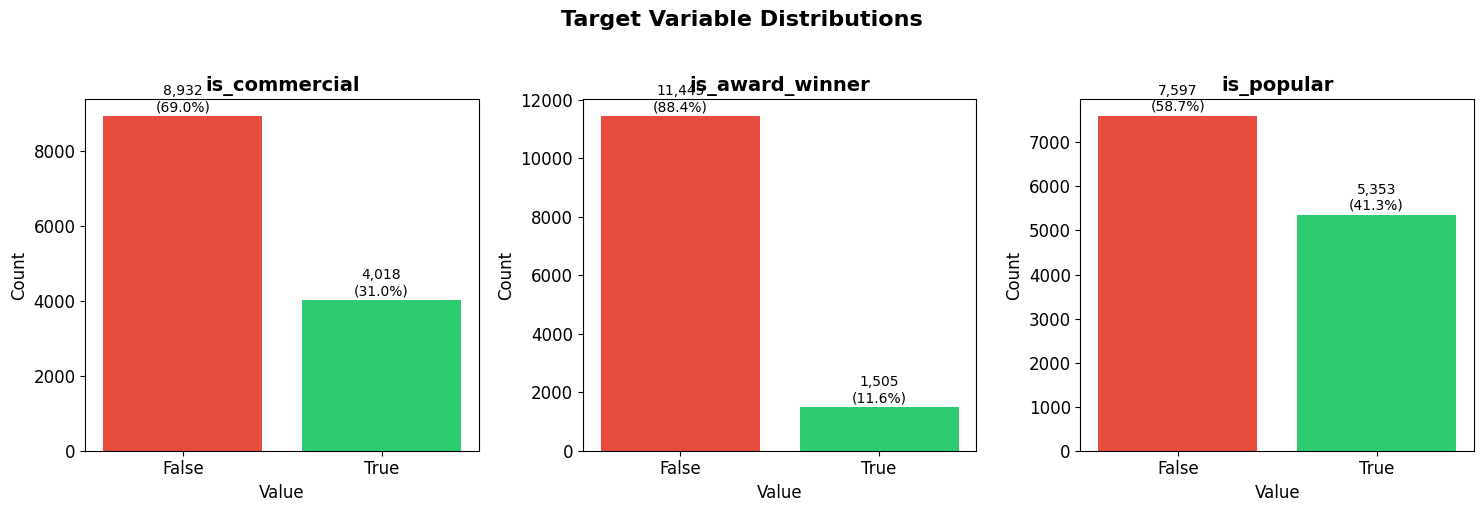

In [6]:
plot_target_distributions(df, FIGURES_DIR)

In [7]:
ct = pd.crosstab(df['is_commercial'], df['is_award_winner'],
                 margins=True, margins_name='Total')
ct

is_award_winner,False,True,Total
is_commercial,,,
False,8227,705,8932
True,3218,800,4018
Total,11445,1505,12950


In [8]:
comm_given_award = df.loc[df['is_award_winner'] == True, 'is_commercial'].mean()
award_given_comm = df.loc[df['is_commercial'] == True, 'is_award_winner'].mean()

print(f"P(commercial | award_winner) = {comm_given_award:.3f}")
print(f"P(award_winner | commercial) = {award_given_comm:.3f}")
print(f"P(commercial)                = {df['is_commercial'].mean():.3f}")
print(f"P(award_winner)              = {df['is_award_winner'].mean():.3f}")

P(commercial | award_winner) = 0.532
P(award_winner | commercial) = 0.199
P(commercial)                = 0.310
P(award_winner)              = 0.116


**Observation:** Commercial success (~30.7%) and award nomination (~11%) are relatively independent events. Award-winning movies are somewhat more likely to be commercially successful than the base rate, but the overlap is modest.

---
## 3. Financial Analysis

Explore budget, revenue, and ROI distributions. Movies with budget=0 or revenue=0 represent missing data.

Movies with budget > 0 AND revenue > 0: 8,920 (68.9%)


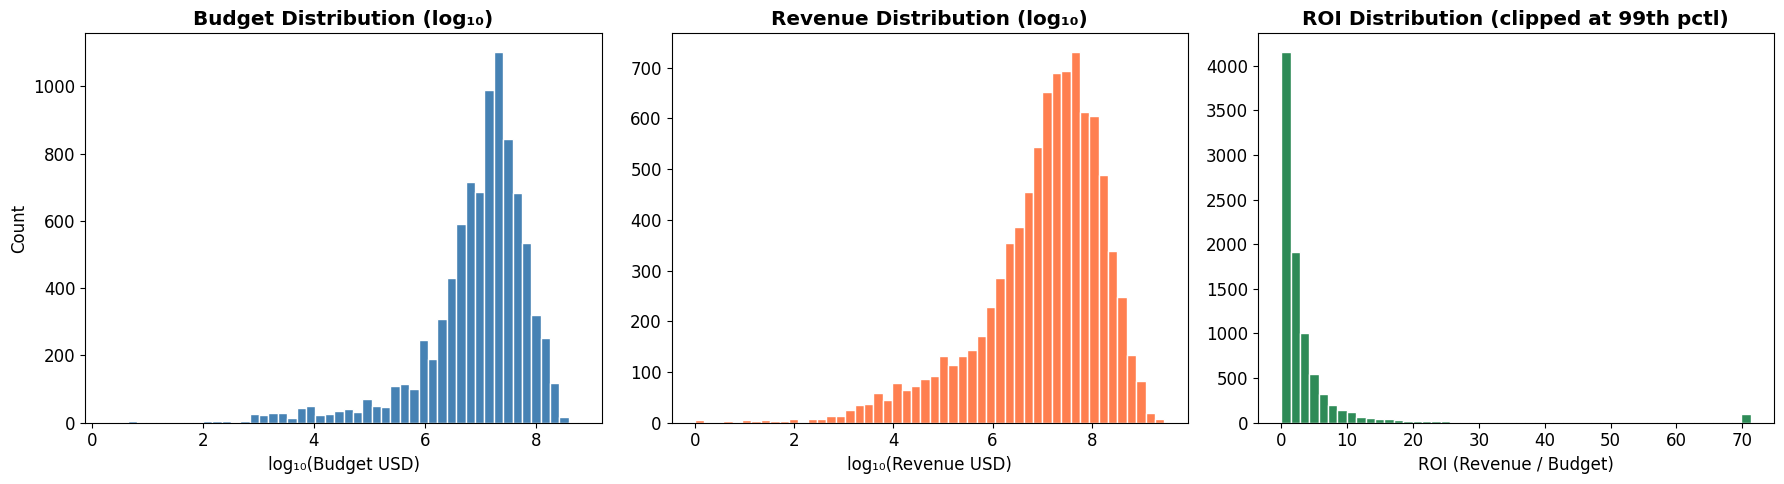

In [9]:
df_financial = plot_financial_distributions(df, FIGURES_DIR)

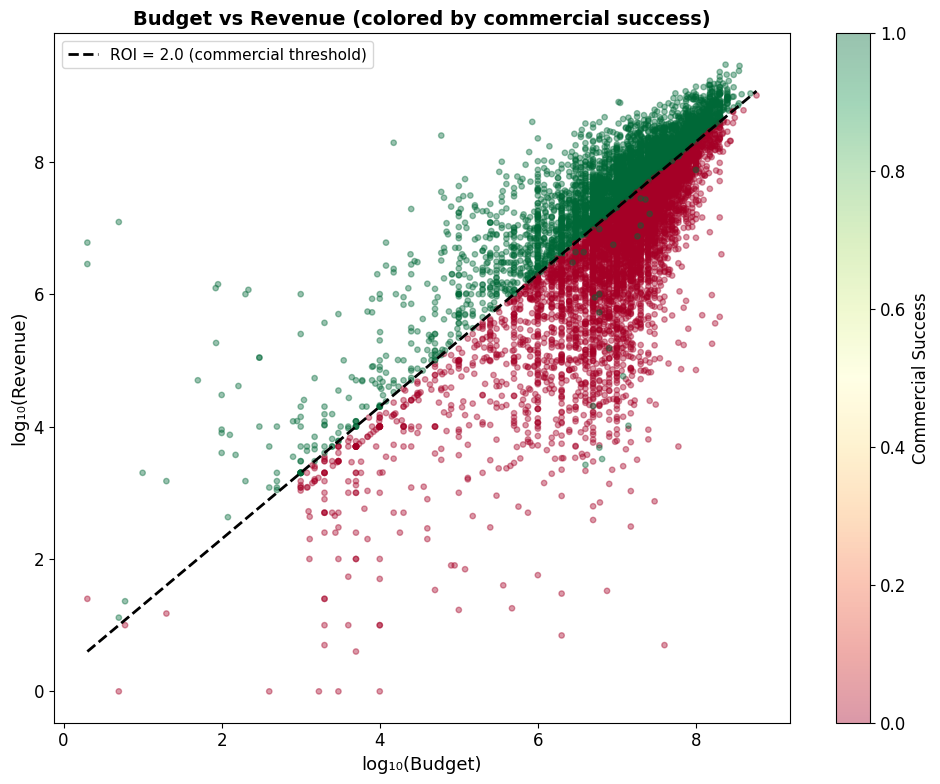

In [10]:
plot_budget_vs_revenue(df_financial, FIGURES_DIR)

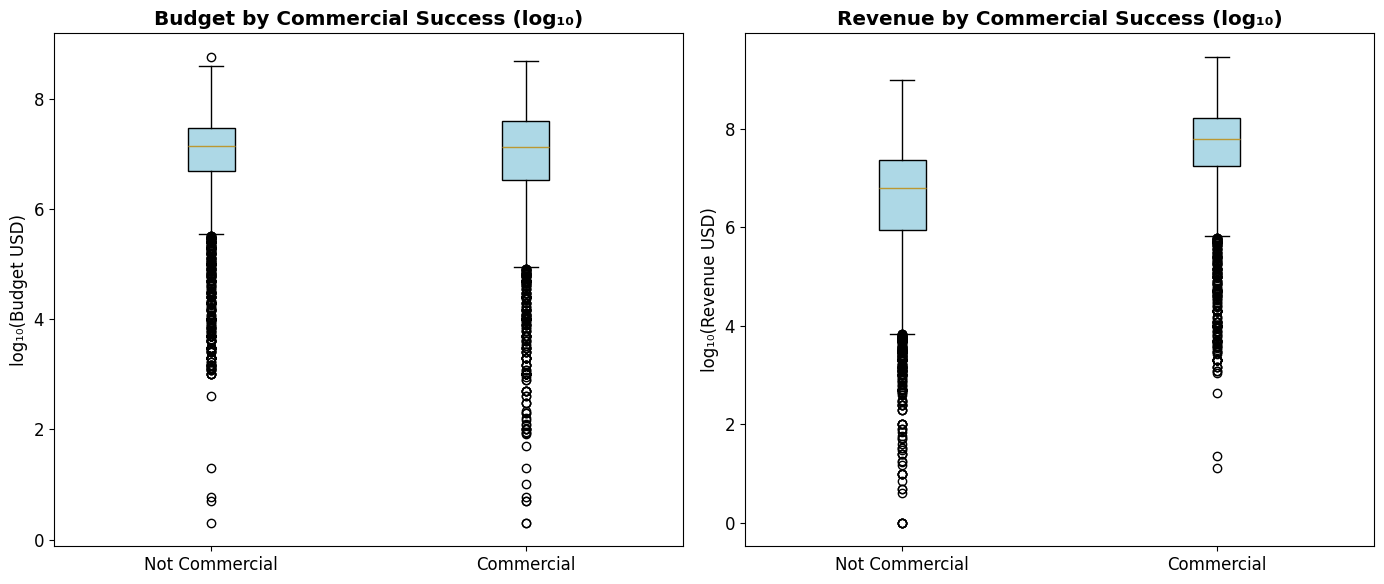

In [11]:
plot_financial_boxplots(df_financial, FIGURES_DIR)

In [12]:
top_roi = df_financial.nlargest(10, 'roi')[['title', 'budget', 'revenue', 'roi', 'release_date']]
top_roi.style.format({'budget': '${:,.0f}', 'revenue': '${:,.0f}', 'roi': '{:.1f}x'})

,title,budget,revenue,roi,release_date
7664,Oy Vey! My Son Is Gay!,$2,"$6,000,007",3000003.5x,2010-06-18
9759,The Beatles: Eight Days a Week - The Touring Years,$5,"$12,283,800",2456760.0x,2016-09-15
3243,The Judas Project,$2,"$2,850,135",1425067.5x,1993-02-19
6031,The Notorious Bettie Page,$90,"$1,410,778",15675.3x,2005-09-14
11959,Scrapper,$84,"$1,234,483",14696.2x,2023-08-25
6501,Paranormal Activity,"$15,000","$193,355,800",12890.4x,2007-09-14
5473,Tarnation,$218,"$1,162,014",5330.3x,2003-10-19
7375,Saved,$200,"$1,000,000",5000.0x,2009-04-11
4362,The Blair Witch Project,"$60,000","$248,639,099",4144.0x,1999-07-14
6073,Hellbent,$85,"$183,066",2153.7x,2005-09-16


**Observation:** Budget and revenue are log-normally distributed. Commercially successful movies have notably higher revenue but only marginally higher budgets — ROI depends more on revenue performance than production cost. The scatter plot shows a clear separation at the ROI=2.0 threshold line.

---
## 4. Genre Analysis

Analyze genre frequencies, commercial success rates per genre, and genre co-occurrence patterns. There are 19 unique genres in the dataset.

Unique genres: 19


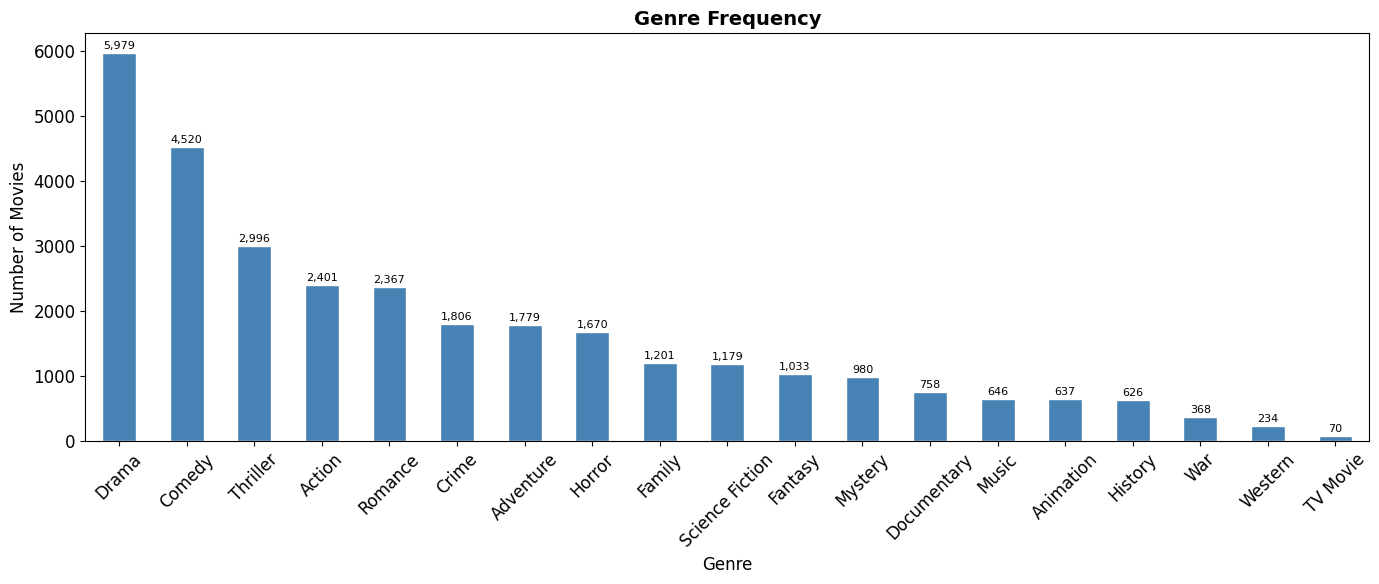

In [13]:
genre_counts = plot_genre_frequency(df, FIGURES_DIR)
unique_genres = sorted(genre_counts.index.tolist())

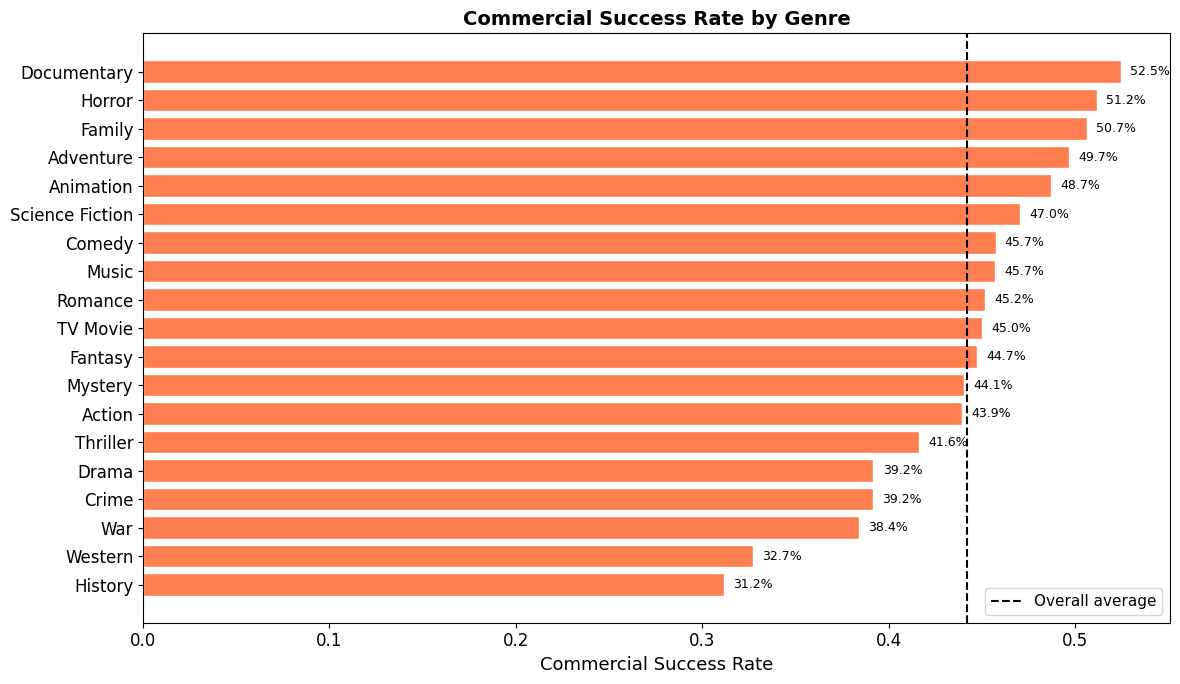

In [14]:
plot_genre_success_rates(df_financial, unique_genres, FIGURES_DIR)

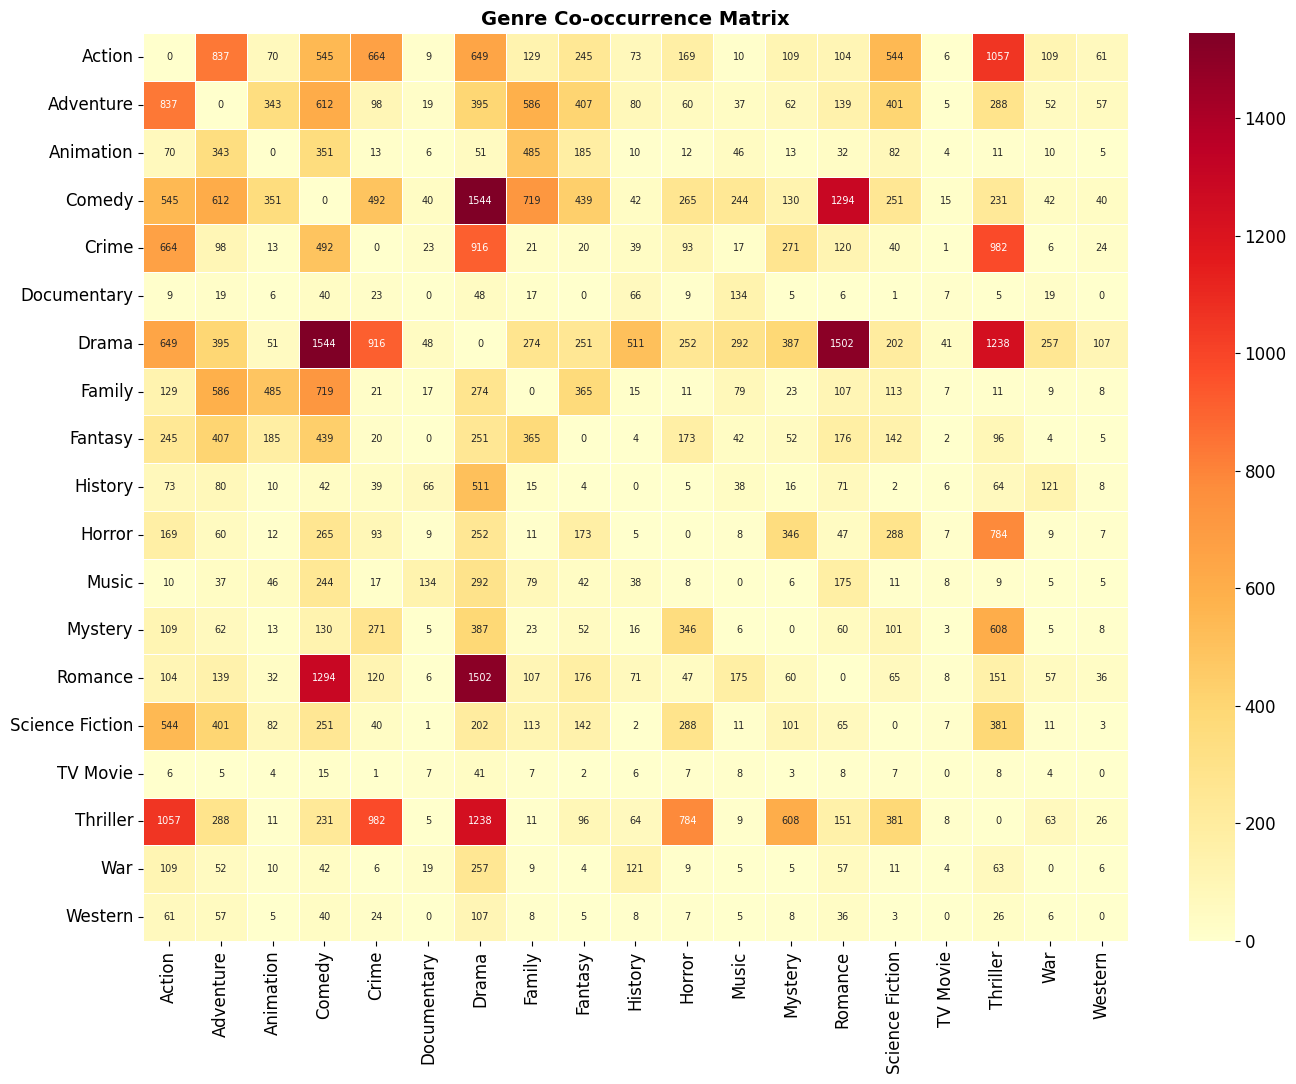

In [15]:
plot_genre_cooccurrence(df, unique_genres, FIGURES_DIR)

**Observation:** Drama is by far the most common genre (5,800+ movies). Action, Adventure, Sci-Fi, and Family have the highest commercial success rates (38–42%), while TV Movie and Documentary are lowest (~12–14%). Drama co-occurs most frequently with Romance, Crime, and Thriller.

---
## 5. Temporal Trends

Analyze how movie production volume, financials, and success rates evolve over time.

In [16]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['decade'] = (df['release_year'] // 10) * 10

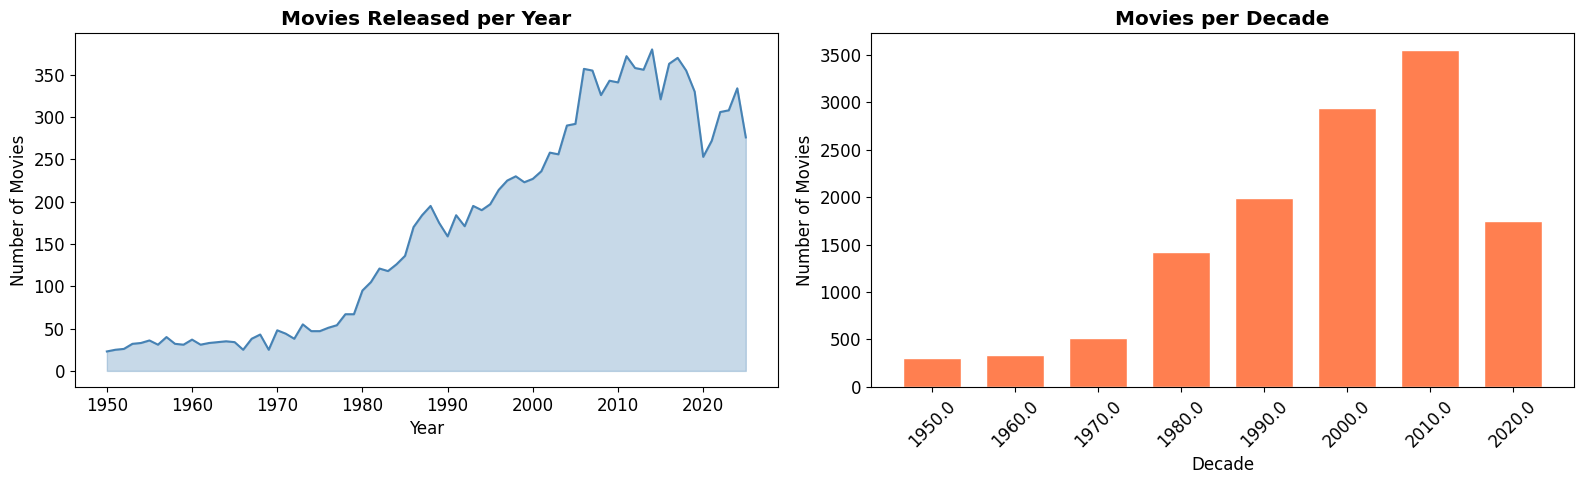

In [17]:
plot_temporal_production(df, FIGURES_DIR)

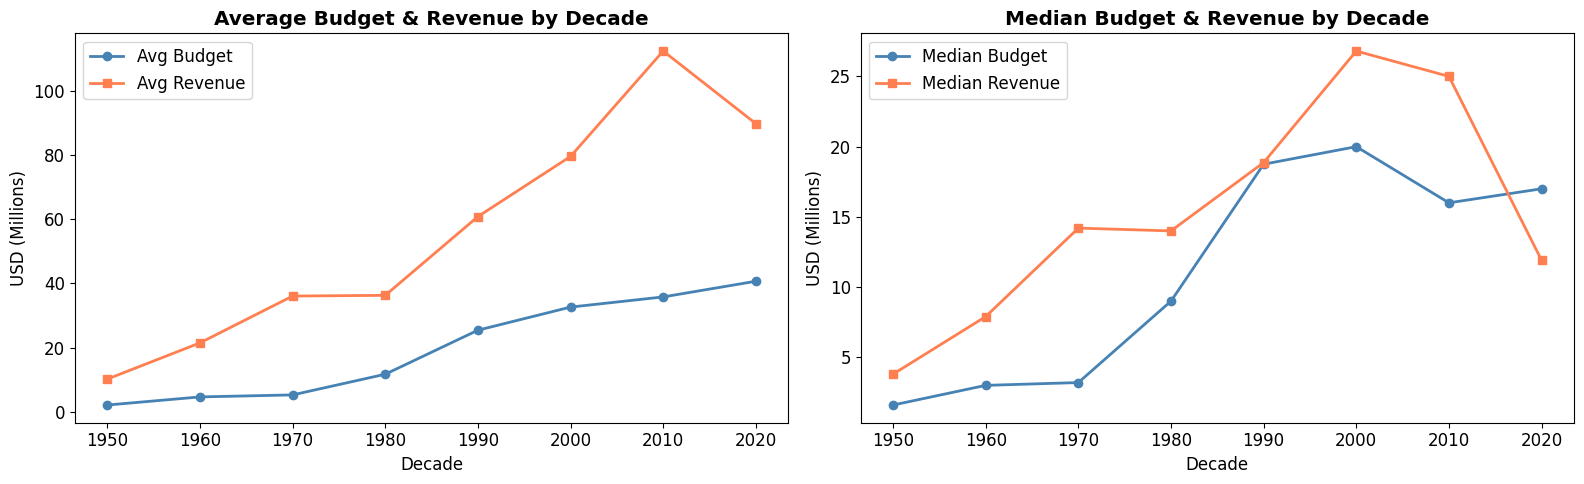

In [18]:
plot_temporal_financials(df, FIGURES_DIR)

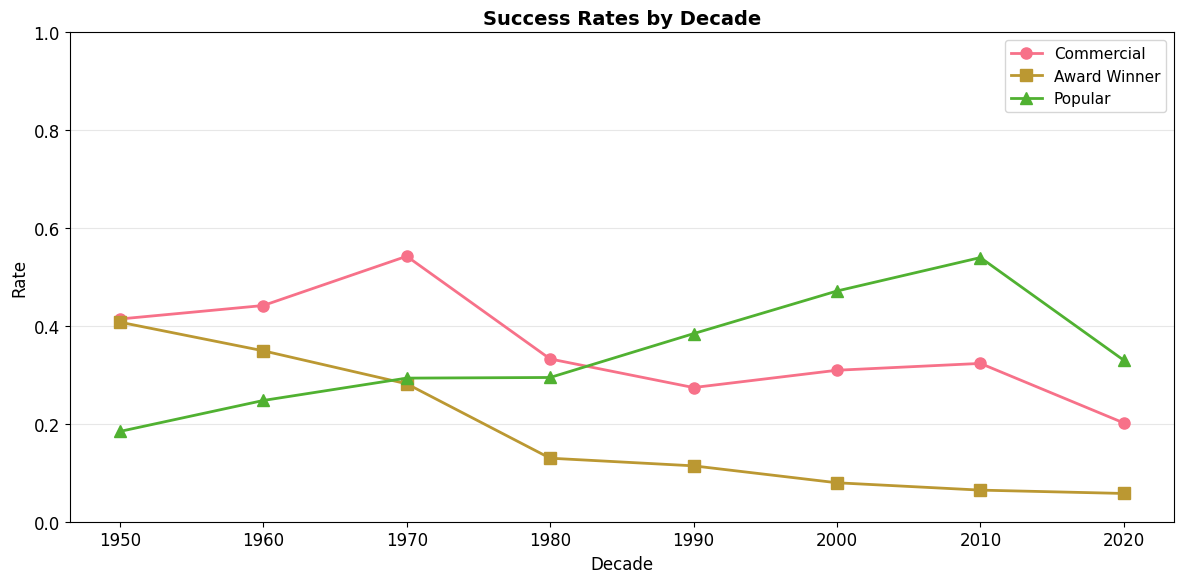

,commercial_rate,award_rate,popular_rate,count
decade,,,,
1950.000000,41.4%,40.8%,18.4%,309
1960.000000,44.2%,34.9%,24.8%,335
1970.000000,54.2%,28.2%,29.3%,518
1980.000000,33.3%,13.0%,29.5%,"1,425"
1990.000000,27.4%,11.4%,38.4%,"1,988"
2000.000000,31.0%,8.0%,47.1%,"2,940"
2010.000000,32.3%,6.5%,54.0%,"3,546"
2020.000000,20.2%,5.8%,33.0%,"1,749"


In [19]:
decade_rates = plot_temporal_success_rates(df, FIGURES_DIR)
decade_rates.style.format({
    'commercial_rate': '{:.1%}',
    'award_rate': '{:.1%}',
    'popular_rate': '{:.1%}',
    'count': '{:,}'
})

**Observation:** Movie production grew dramatically from ~300/decade in the 1950s to ~3,500 in the 2010s. Commercial success rates peaked in the 1970s (~54%) and declined to ~19% in the 2020s. Award rates dropped from ~41% (1950s) to ~6% (2010s–2020s) as the total film pool grew while Oscar slots remained fixed.

---
## 6. Runtime and Votes

Explore the distributions of runtime and vote count, and their relationship with commercial success.

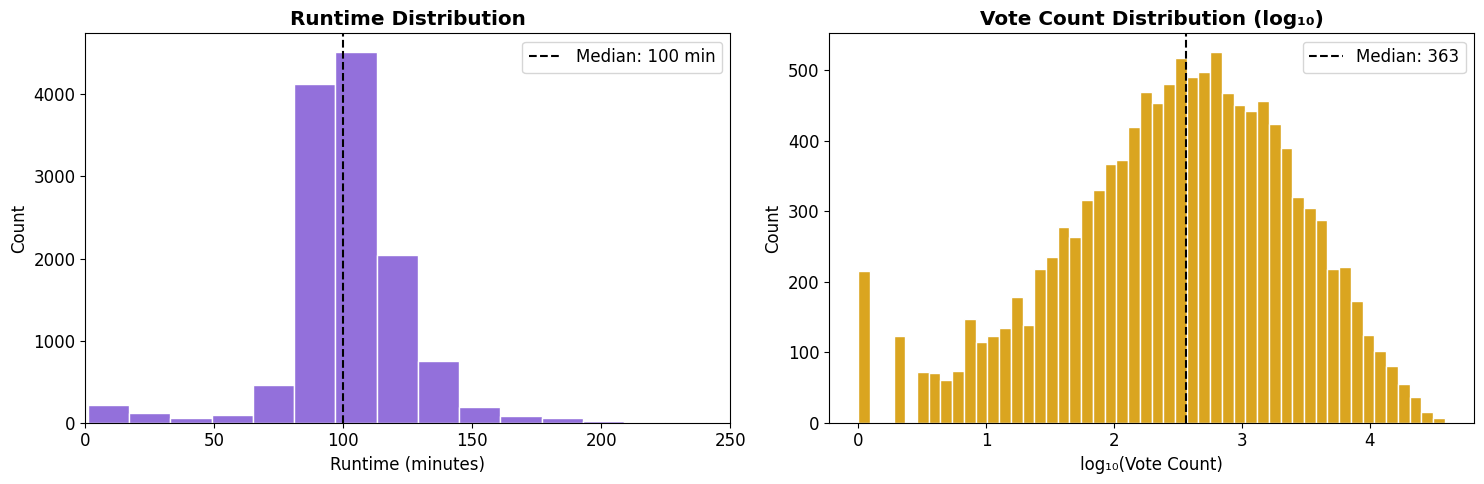

In [20]:
plot_runtime_votes_distributions(df, FIGURES_DIR)

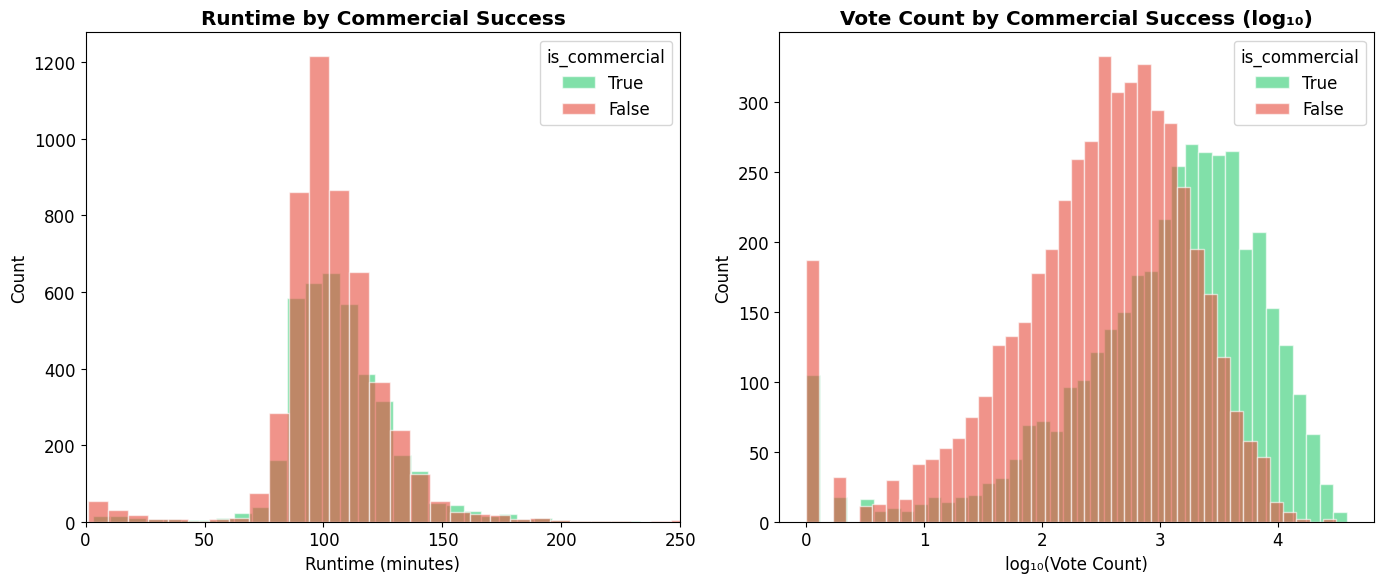

In [21]:
plot_runtime_votes_by_success(df, FIGURES_DIR)

**Observation:** Median runtime is ~100 minutes with a right-skewed tail. Vote count is log-normally distributed. Commercially successful movies tend to have higher vote counts (stronger audience engagement) and slightly longer runtimes.

---
## 7. Missing Data

Assess data completeness and define the modeling-eligible subset (budget > 0, revenue > 0, runtime > 0).

In [22]:
zero_counts = {
    'budget = 0': (df['budget'] == 0).sum(),
    'revenue = 0': (df['revenue'] == 0).sum(),
    'runtime = 0': (df['runtime'] == 0).sum(),
    'vote_count = 0': (df['vote_count'] == 0).sum()
}

missing_df = pd.DataFrame({
    'count': zero_counts,
    'percentage': {k: v / len(df) * 100 for k, v in zero_counts.items()}
})
missing_df.style.format({'count': '{:,}', 'percentage': '{:.2f}%'})

,count,percentage
budget = 0,"3,799",29.34%
revenue = 0,438,3.38%
runtime = 0,32,0.25%
vote_count = 0,697,5.38%


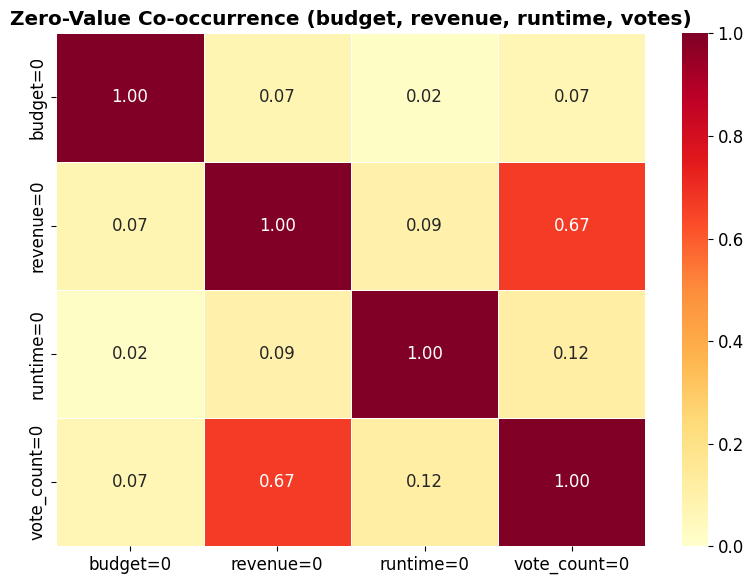

In [23]:
plot_missing_data_heatmap(df, FIGURES_DIR)

In [24]:
targets = ['is_commercial', 'is_award_winner', 'is_popular']
modeling_mask = (df['budget'] > 0) & (df['revenue'] > 0) & (df['runtime'] > 0)
n_eligible = modeling_mask.sum()

print(f"Modeling-eligible movies: {n_eligible:,} / {len(df):,} ({n_eligible/len(df)*100:.1f}%)")
print(f"Excluded: {len(df) - n_eligible:,} ({(len(df) - n_eligible)/len(df)*100:.1f}%)")
print()

for target in targets:
    subset = df[modeling_mask]
    rate = subset[target].mean()
    print(f"  {target}: {subset[target].sum():,} True / {len(subset):,} ({rate:.1%})")

Modeling-eligible movies: 8,890 / 12,950 (68.6%)
Excluded: 4,060 (31.4%)

  is_commercial: 3,918 True / 8,890 (44.1%)
  is_award_winner: 1,139 True / 8,890 (12.8%)
  is_popular: 4,946 True / 8,890 (55.6%)


**Observation:** Budget is the primary source of missing data (29.3% have budget=0). After applying modeling eligibility criteria (budget > 0, revenue > 0, runtime > 0), we retain ~8,890 movies (68.6%). The class distributions in the modeling subset are reasonable for classification.

---
## 8. Subtitle Coverage

Check how many movies have corresponding subtitle files in `data/raw/subtitles/`.

In [25]:
subtitle_files = list(SUBTITLES_DIR.glob('*.txt'))
subtitle_ids = {int(f.stem) for f in subtitle_files if f.stem.isdigit()}

df['has_subtitle'] = df['id'].isin(subtitle_ids)

n_subs = df['has_subtitle'].sum()
print(f"Subtitle files found: {len(subtitle_files):,}")
print(f"Movies with subtitles: {n_subs:,} / {len(df):,} ({n_subs/len(df)*100:.1f}%)")

Subtitle files found: 7,611
Movies with subtitles: 7,611 / 12,950 (58.8%)


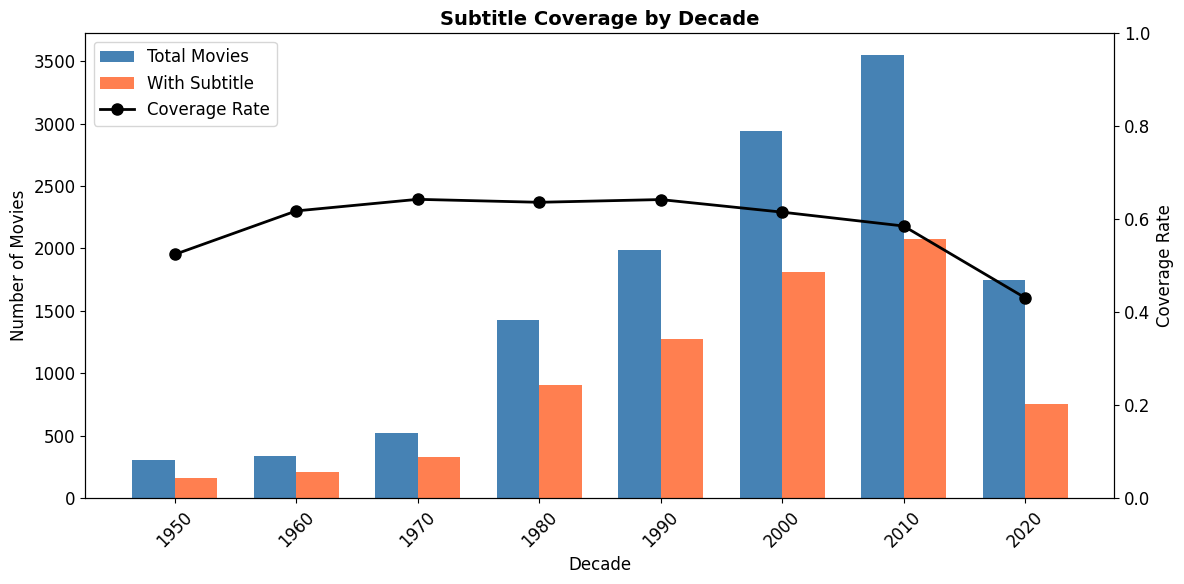

In [26]:
plot_subtitle_coverage(df, FIGURES_DIR)

**Observation:** Subtitle coverage is ~58%, with higher rates for more recent decades. This is sufficient for meaningful NLP analysis, though ~42% of movies will lack text-based features.

---
## 9. Feature Correlations

Examine linear correlations between numeric features and compute point-biserial correlations with the binary targets.

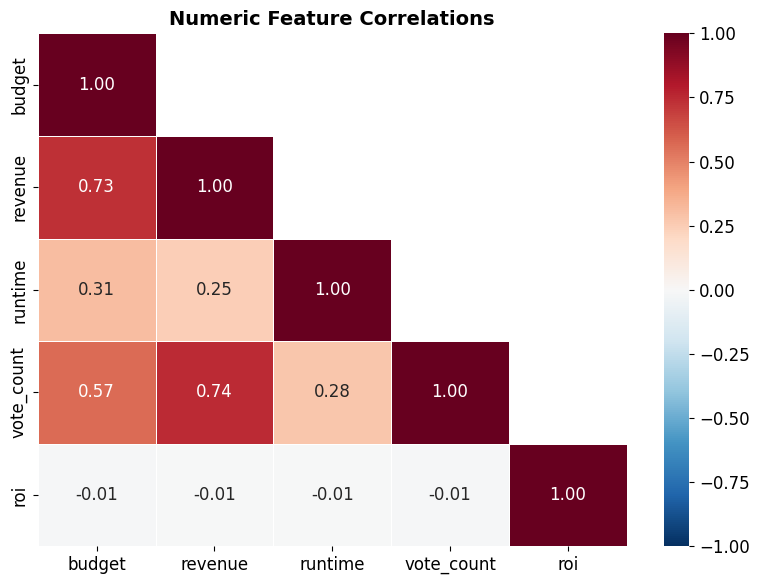

In [27]:
plot_feature_correlations(df_financial, FIGURES_DIR)

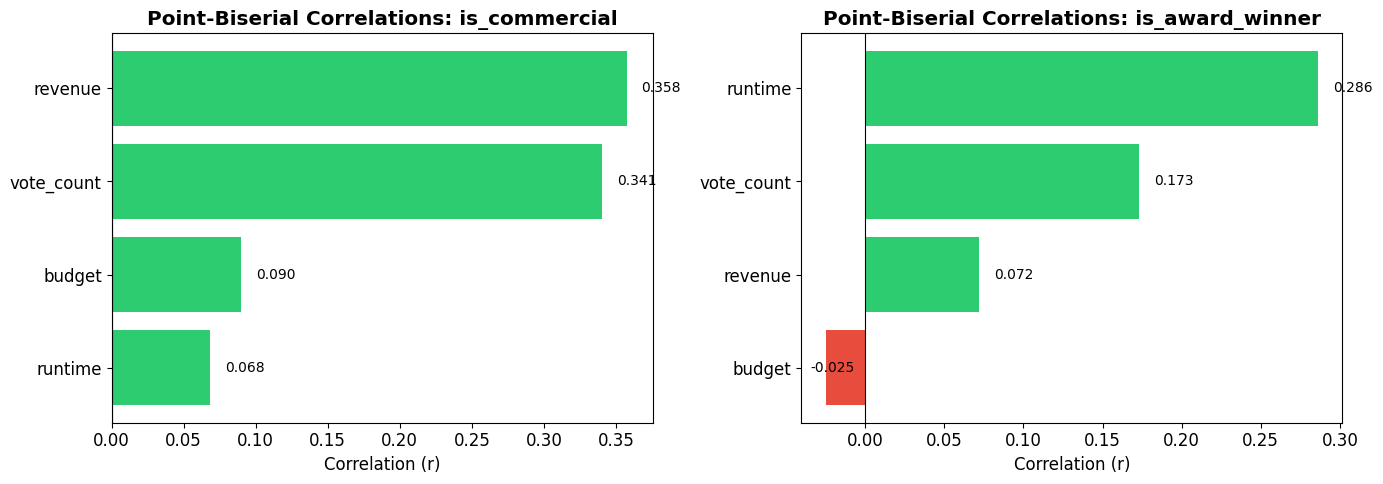

In [28]:
plot_point_biserial_correlations(df_financial, FIGURES_DIR)

**Observation:** For commercial success, `vote_count` (r≈0.42) and `revenue` (r≈0.42, excluded from modeling due to leakage) are the strongest predictors. For award prediction, `runtime` (r≈0.21) is the top feature — award films tend to be longer. Budget has weak correlation with awards (r≈0.02).

---
## 10. Key Findings

### Summary of EDA Insights

1. **Dataset scope:** 12,950 movies (1950–2024). After filtering for budget > 0, revenue > 0, runtime > 0, ~8,890 are eligible for modeling (68.6%).

2. **Target distributions:** Commercial success (ROI ≥ 2.0) ~44% in modeling subset (near-balanced). Award nomination ~13% (imbalanced — will require SMOTE or class weighting).

3. **Financial patterns:** Budget and revenue are log-normally distributed. Commercially successful movies have much higher revenue but only marginally higher budgets — audience engagement matters more than production cost.

4. **Genre effects:** Action, Adventure, Sci-Fi, and Family genres have the highest commercial success rates (38–42%). Documentary and TV Movie are the lowest (~12–14%). Genre is a strong predictive signal.

5. **Temporal trends:** Movie volume has grown 10x since the 1950s, but commercial success and award rates have declined steadily — reflecting increased competition.

6. **Runtime and votes:** Vote count (r≈0.42 with commercial success) is the strongest single predictor among numeric features. Runtime correlates more with award nominations (r≈0.21) than commercial success.

7. **Subtitle coverage:** 58.8% of movies have subtitle files, enabling NLP feature extraction for the majority of the dataset. Coverage is higher for recent decades.

8. **Key predictors for commercial success:** vote_count > budget > runtime > genre features.

9. **Key predictors for award nomination:** runtime > vote_count > revenue (not leaked) > budget.

10. **Data leakage note:** Revenue must be excluded from commercial success prediction (ROI = revenue/budget). It is safe to use for award prediction.